<a href="https://colab.research.google.com/github/sharvani1357/Deep-Learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import mnist
from keras import  Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


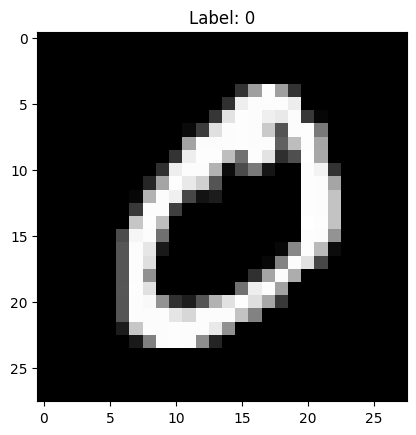

In [7]:
#basic data visulization
img=X_train[1,:,:]
label=y_train[1]
plt.imshow(img,cmap='gray')
plt.title(f"Label: {label}")
plt.show()

## Data Preprocessing
### Normalize the data and reshape it for CNN input

In [9]:
#Normalize and reshape
X_train=X_train.reshape(-1,28,28,1).astype('float32')/255
X_test=X_test.reshape(-1,28,28,1).astype('float')/255

#one-hot encode labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

## Model Building
### Buid a CNN model using keras Sequential API

In [12]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [14]:
history=model.fit(X_train,y_train,epochs=5,batch_size=128,validation_split=0.2)
#epochs -> Model sees dataset 5 times
#batch-size-> processes 128 images per step
#validation-split->uses 20% training data for validation

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.8400 - loss: 0.5319 - val_accuracy: 0.9756 - val_loss: 0.0851
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.9775 - loss: 0.0733 - val_accuracy: 0.9835 - val_loss: 0.0580
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9836 - loss: 0.0502 - val_accuracy: 0.9871 - val_loss: 0.0492
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.9895 - loss: 0.0334 - val_accuracy: 0.9842 - val_loss: 0.0528
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 117ms/step - accuracy: 0.9907 - loss: 0.0277 - val_accuracy: 0.9893 - val_loss: 0.0368


In [15]:
test_loss,test_acc=model.evaluate(X_test,y_test)
print(f"Test accuracy: {test_acc}")
print(f"Test loss:{test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9858 - loss: 0.0424
Test accuracy: 0.9890999794006348
Test loss:0.03281564265489578


## Prediction
### Make Predictions on new data samples

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


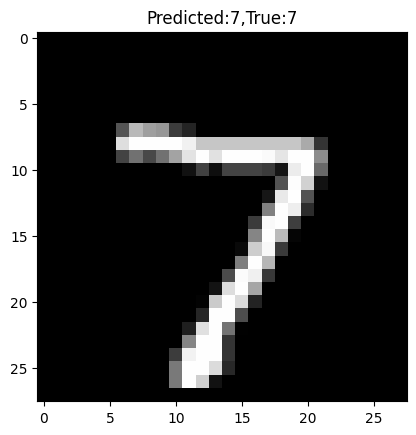

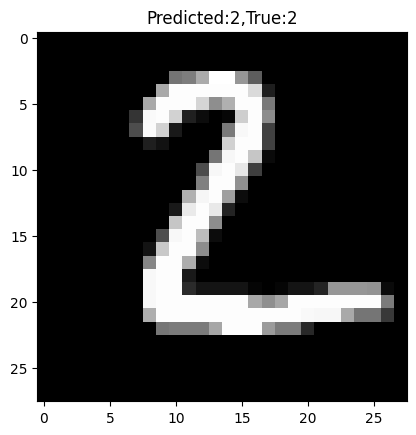

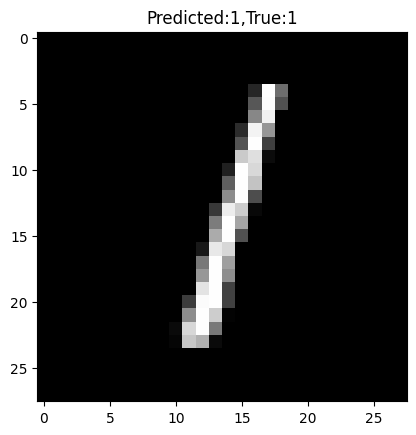

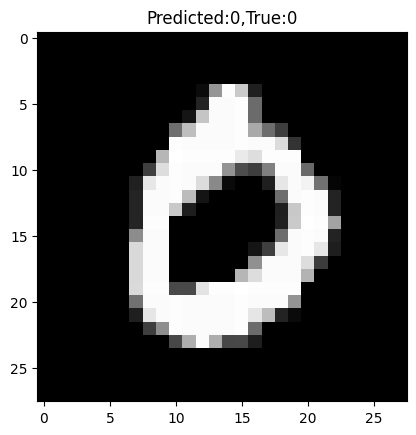

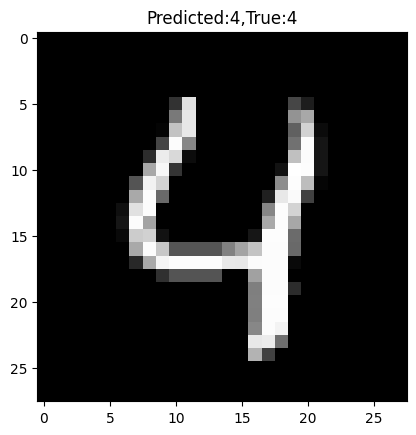

In [17]:
#predict on the few test samples
predictions=model.predict(X_test[:5])
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5],axis=1)
for i in range(5):
  plt.imshow(X_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Predicted:{predicted_classes[i]},True:{true_classes[i]}")
  plt.show()